---

# Import Required Libraries

---

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import joblib
print("Everything is imported successfully!")

Everything is imported successfully!


---

# Preprocess Data

---

## Import & Load Dataset

In [4]:
data = pd.read_csv("data.csv")

## Dataset Details

In [6]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
data.shape

(303, 14)

In [10]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

---

# Train & Evaluate Models

---

In [11]:
X = data.drop(columns = 'target')
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [12]:
# Model 01: Logistic Regression
print("Model 01: Logistic Regression")
print("_" * 150)
model_01 = LogisticRegression(max_iter=1000)
model_01.fit(X_train, y_train)
# Training
y_train_pred_01 = model_01.predict(X_train)
y_train_prob_01 = model_01.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_01))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_01))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_01))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_01))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_01))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_01))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_01))
print("_" * 150)
# Testing
y_test_pred_01 = model_01.predict(X_test)
y_test_prob_01 = model_01.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_01))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_01))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_01))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_01))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_01))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_01))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_01))
print("_" * 150)

Model 01: Logistic Regression
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.8636363636363636
Training Precision Score:  0.8472222222222222
Training Recall Score:  0.9172932330827067
Training F1 Score:  0.8808664259927798
Training ROC AUC Score:  0.9226046768296888
Training Confusion Matrix:
 [[ 87  22]
 [ 11 122]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84       109
           1       0.85      0.92      0.88       133

    accuracy                           0.86       242
   macro avg       0.87      0.86      0.86       242
weighted avg       0.87      0.86      0.86       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.8852459016393

In [13]:
# Model 02: Ridge Classifier
print("Model 02: Ridge Classifier")
print("_" * 150)
model_02 = Pipeline([("scaler", StandardScaler()), ("ridge", RidgeClassifier())])
model_02.fit(X_train, y_train)
# Training
y_train_pred_02 = model_02.predict(X_train)
y_train_prob_02 = model_02.decision_function(X_train)
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_02))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_02))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_02))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_02))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_02))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_02))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_02))
print("_" * 150)
# Testing
y_test_pred_02 = model_02.predict(X_test)
y_test_prob_02 = model_02.decision_function(X_test)
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_02))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_02))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_02))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_02))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_02))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_02))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_02))
print("_" * 150)

Model 02: Ridge Classifier
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.859504132231405
Training Precision Score:  0.8322147651006712
Training Recall Score:  0.9323308270676691
Training F1 Score:  0.8794326241134752
Training ROC AUC Score:  0.9217079395737049
Training Confusion Matrix:
 [[ 84  25]
 [  9 124]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83       109
           1       0.83      0.93      0.88       133

    accuracy                           0.86       242
   macro avg       0.87      0.85      0.86       242
weighted avg       0.86      0.86      0.86       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.8688524590163934


In [14]:
# Model 03: K-Nearest Neighbors
print("Model 03: K-Nearest Neighbors")
print("_" * 150)
model_03 = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
model_03.fit(X_train, y_train)
# Training
y_train_pred_03 = model_03.predict(X_train)
y_train_prob_03 = model_03.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_03))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_03))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_03))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_03))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_03))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_03))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_03))
print("_" * 150)
# Testing
y_test_pred_03 = model_03.predict(X_test)
y_test_prob_03 = model_03.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_03))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_03))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_03))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_03))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_03))
print("Testing Confusion Mratix:\n", confusion_matrix(y_test, y_test_pred_03))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_03))
print("_" * 150)

Model 03: K-Nearest Neighbors
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.8553719008264463
Training Precision Score:  0.8450704225352113
Training Recall Score:  0.9022556390977443
Training F1 Score:  0.8727272727272727
Training ROC AUC Score:  0.9329861350624267
Training Confusion Matrix:
 [[ 87  22]
 [ 13 120]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83       109
           1       0.85      0.90      0.87       133

    accuracy                           0.86       242
   macro avg       0.86      0.85      0.85       242
weighted avg       0.86      0.86      0.85       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.9016393442622

In [15]:
# Model 04: Support Vector Classifier
print("Model 04: Support Vector Classifier")
print("_" * 150)
model_04 = Pipeline([("scaler", StandardScaler()), ("svc", SVC(probability=True))])
model_04.fit(X_train, y_train)
# Training
y_train_pred_04 = model_04.predict(X_train)
y_train_prob_04 = model_04.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_04))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_04))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_04))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_04))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_04))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_04))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_04))
print("_" * 150)
# Testing
y_test_pred_04 = model_04.predict(X_test)
y_test_prob_04 = model_04.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_04))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_04))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_04))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_04))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_04))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_04))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_04))
print("_" * 150)

Model 04: Support Vector Classifier
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.9214876033057852
Training Precision Score:  0.9130434782608695
Training Recall Score:  0.9473684210526315
Training F1 Score:  0.9298892988929889
Training ROC AUC Score:  0.9635786714492653
Training Confusion Matrix:
 [[ 97  12]
 [  7 126]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91       109
           1       0.91      0.95      0.93       133

    accuracy                           0.92       242
   macro avg       0.92      0.92      0.92       242
weighted avg       0.92      0.92      0.92       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.8688524

e:\Shabd\Academics\Semester 5\ITR Lab\Heart Disease Predictor\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [16]:
# Model 05: Gaussian Naive Bayes Classifier
print("Model 05: Gaussian Naive Bayes Classifier")
print("_" * 150)
model_05 = GaussianNB()
model_05.fit(X_train, y_train)
# Training
y_train_pred_05 = model_05.predict(X_train)
y_train_prob_05 = model_05.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_05))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_05))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_05))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_05))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_05))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_05))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_05))
print("_" * 150)
# Testing
y_test_pred_05 = model_05.predict(X_test)
y_test_prob_05 = model_05.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_05))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_05))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_05))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_05))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_05))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_05))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_05))
print("_" * 150)

Model 05: Gaussian Naive Bayes Classifier
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.8181818181818182
Training Precision Score:  0.8201438848920863
Training Recall Score:  0.8571428571428571
Training F1 Score:  0.8382352941176471


Training ROC AUC Score:  0.9092915775677726
Training Confusion Matrix:
 [[ 84  25]
 [ 19 114]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79       109
           1       0.82      0.86      0.84       133

    accuracy                           0.82       242
   macro avg       0.82      0.81      0.82       242
weighted avg       0.82      0.82      0.82       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.8688524590163934
Testing Precision Score:  0.9
Testing Recall Score:  0.84375
Testing F1 Score:  0.8709677419354839
Testing ROC AUC Score:  0.894396551724138
Testing Confusion Matrix:
 [[26  3]
 [ 5 27]]
Testing Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.9

In [17]:
# Model 06: Decision Tree Classifier
print("Model 06: Decision Tree Classifier")
print("_" * 150)
model_06 = DecisionTreeClassifier(random_state=42)
model_06.fit(X_train, y_train)
# Training
y_train_pred_06 = model_06.predict(X_train)
y_train_prob_06 = model_06.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_06))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_06))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_06))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_06))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_06))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_06))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_06))
print("_" * 150)
# Testing
y_test_pred_06 = model_06.predict(X_test)
y_test_prob_06 = model_06.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_06))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_06))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_06))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_06))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_06))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_06))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_06))
print("_" * 150)

Model 06: Decision Tree Classifier
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  1.0
Training Precision Score:  1.0
Training Recall Score:  1.0
Training F1 Score:  1.0
Training ROC AUC Score:  1.0
Training Confusion Matrix:
 [[109   0]
 [  0 133]]
Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       133

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.7540983606557377
Testing Precision Score:  0.84
Testing Recall Score:  0.65625
Test

In [18]:
# Model 06.1: Decision Tree Classifier Improvement
print("Model 06.1: Decision Tree Classifier Improvement")
print("_" * 150)
model_06_1 = DecisionTreeClassifier(max_depth=4, random_state=42)
model_06_1.fit(X_train, y_train)
# Training
y_train_pred_06_1 = model_06_1.predict(X_train)
y_train_prob_06_1 = model_06_1.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_06_1))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_06_1))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_06_1))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_06_1))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_06_1))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_06_1))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_06_1))
print("_" * 150)
# Testing
y_test_pred_06_1 = model_06_1.predict(X_test)
y_test_prob_06_1 = model_06_1.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_06_1))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_06_1))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_06_1))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_06_1))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_06_1))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_06_1))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_06_1))
print("_" * 150)

Model 06.1: Decision Tree Classifier Improvement
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.8842975206611571
Training Precision Score:  0.8523489932885906
Training Recall Score:  0.9548872180451128
Training F1 Score:  0.900709219858156
Training ROC AUC Score:  0.9374353314478858
Training Confusion Matrix:
 [[ 87  22]
 [  6 127]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86       109
           1       0.85      0.95      0.90       133

    accuracy                           0.88       242
   macro avg       0.89      0.88      0.88       242
weighted avg       0.89      0.88      0.88       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score

In [19]:
# Model 07: Random Forest Classifier
print("Model 07: Random Forest Classifier")
print("_" * 150)
model_07 = RandomForestClassifier(random_state=42)
model_07.fit(X_train, y_train)
# Training
y_train_pred_07 = model_07.predict(X_train)
y_train_prob_07 = model_07.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_07))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_07))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_07))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_07))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_07))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_07))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_07))
print("_" * 150)
# Testing
y_test_pred_07 = model_07.predict(X_test)
y_test_prob_07 = model_07.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_07))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_07))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_07))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_07))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_07))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_07))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_07))
print("_" * 150)

Model 07: Random Forest Classifier
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  1.0
Training Precision Score:  1.0
Training Recall Score:  1.0
Training F1 Score:  1.0
Training ROC AUC Score:  1.0
Training Confusion Matrix:
 [[109   0]
 [  0 133]]
Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       133

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.8360655737704918
Testing Precision Score:  0.84375
Testing Recall Score:  0.84375
T

In [20]:
# Model 07.1: Random Forest Classifier Improvement
print("Model 07.1: Random Forest Classifier Improvement")
print("_" * 150)
model_07_1 = RandomForestClassifier(max_depth=4, random_state=42)
model_07_1.fit(X_train, y_train)
# Training
y_train_pred_07_1 = model_07_1.predict(X_train)
y_train_prob_07_1 = model_07_1.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_07_1))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_07_1))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_07_1))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_07_1))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_07_1))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_07_1))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_07_1))
print("_" * 150)
# Testing
y_test_pred_07_1 = model_07_1.predict(X_test)
y_test_prob_07_1 = model_07_1.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_07_1))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_07_1))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_07_1))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_07_1))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_07_1))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_07_1))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_07_1))
print("_" * 150)

Model 07.1: Random Forest Classifier Improvement
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.9090909090909091
Training Precision Score:  0.8827586206896552
Training Recall Score:  0.9624060150375939
Training F1 Score:  0.920863309352518
Training ROC AUC Score:  0.9735807408429329
Training Confusion Matrix:
 [[ 92  17]
 [  5 128]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89       109
           1       0.88      0.96      0.92       133

    accuracy                           0.91       242
   macro avg       0.92      0.90      0.91       242
weighted avg       0.91      0.91      0.91       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score

In [21]:
# Model 08: Gradient Boosting Classifier
print("Model 08: Gradient Boosting Classifier")
print("_" * 150)
model_08 = GradientBoostingClassifier(random_state=42)
model_08.fit(X_train, y_train)
# Training
y_train_pred_08 = model_08.predict(X_train)
y_train_prob_08 = model_08.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_08))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_08))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_08))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_08))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_08))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_08))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_08))
print("_" * 150)
# Testing
y_test_pred_08 = model_08.predict(X_test)
y_test_prob_08 = model_08.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_08))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_08))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_08))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_08))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_08))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_08))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_08))
print("_" * 150)

Model 08: Gradient Boosting Classifier
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  1.0
Training Precision Score:  1.0
Training Recall Score:  1.0
Training F1 Score:  1.0
Training ROC AUC Score:  1.0
Training Confusion Matrix:
 [[109   0]
 [  0 133]]
Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       133

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy Score:  0.7704918032786885
Testing Precision Score:  0.8
Testing Recall Score:  0.75
Test

In [22]:
# Model 08.1: Gradient Boosting Classifier Improvement
print("Model 08.1: Gradient Boosting Classifier Improvement")
print("_" * 150)
model_08_1 = GradientBoostingClassifier(max_depth=1, random_state=42)
model_08_1.fit(X_train, y_train)
# Training
y_train_pred_08_1 = model_08_1.predict(X_train)
y_train_prob_08_1 = model_08_1.predict_proba(X_train)[:, 1]
print("Training Accuracy Score: ", accuracy_score(y_train, y_train_pred_08_1))
print("Training Precision Score: ", precision_score(y_train, y_train_pred_08_1))
print("Training Recall Score: ", recall_score(y_train, y_train_pred_08_1))
print("Training F1 Score: ", f1_score(y_train, y_train_pred_08_1))
print("Training ROC AUC Score: ", roc_auc_score(y_train, y_train_prob_08_1))
print("Training Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred_08_1))
print("Training Classification Report:\n", classification_report(y_train, y_train_pred_08_1))
print("_" * 150)
# Testing
y_test_pred_08_1 = model_08_1.predict(X_test)
y_test_prob_08_1 = model_08_1.predict_proba(X_test)[:, 1]
print("Testing Accuracy Score: ", accuracy_score(y_test, y_test_pred_08_1))
print("Testing Precision Score: ", precision_score(y_test, y_test_pred_08_1))
print("Testing Recall Score: ", recall_score(y_test, y_test_pred_08_1))
print("Testing F1 Score: ", f1_score(y_test, y_test_pred_08_1))
print("Testing ROC AUC Score: ", roc_auc_score(y_test, y_test_prob_08_1))
print("Testing Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_08_1))
print("Testing Classification Report:\n", classification_report(y_test, y_test_pred_08_1))
print("_" * 150)

Model 08.1: Gradient Boosting Classifier Improvement
______________________________________________________________________________________________________________________________________________________
Training Accuracy Score:  0.8884297520661157
Training Precision Score:  0.8785714285714286
Training Recall Score:  0.924812030075188
Training F1 Score:  0.9010989010989011
Training ROC AUC Score:  0.9517831275436297
Training Confusion Matrix:
 [[ 92  17]
 [ 10 123]]
Training Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87       109
           1       0.88      0.92      0.90       133

    accuracy                           0.89       242
   macro avg       0.89      0.88      0.89       242
weighted avg       0.89      0.89      0.89       242

______________________________________________________________________________________________________________________________________________________
Testing Accuracy S

---

# Data Visualization

---

## Target Distribution(Bar Chart)

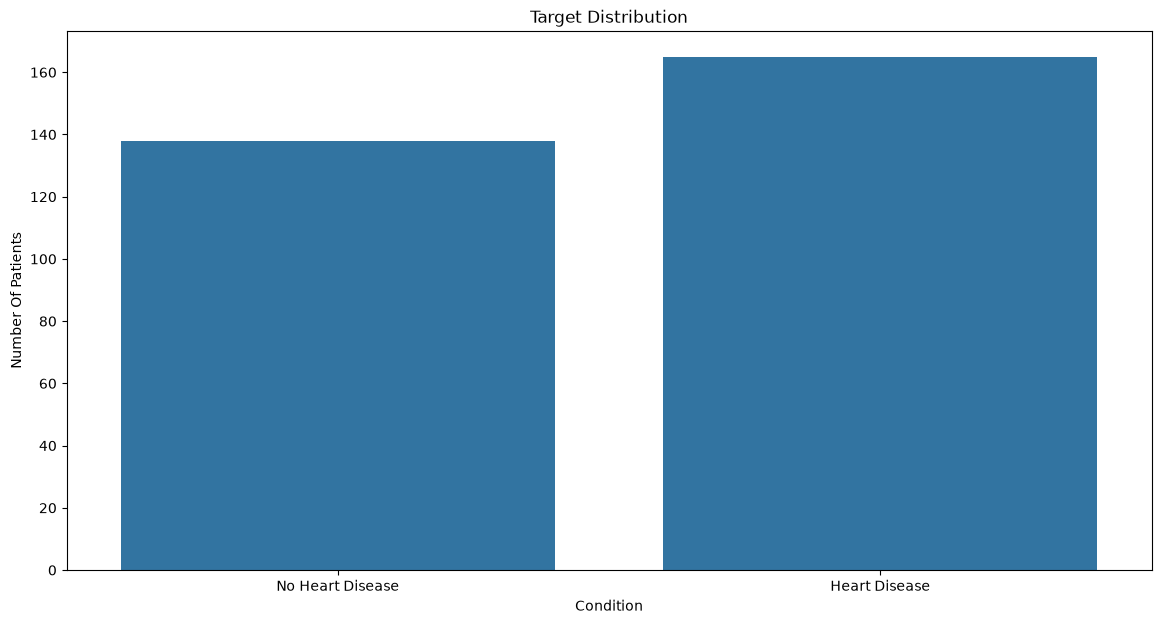

In [23]:
plt.figure(figsize = (14, 7))
sns.countplot(data = data, x = 'target')
plt.title("Target Distribution")
plt.xlabel("Condition")
plt.ylabel("Number Of Patients")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.show()

## Feature Correlation(Heatmap)

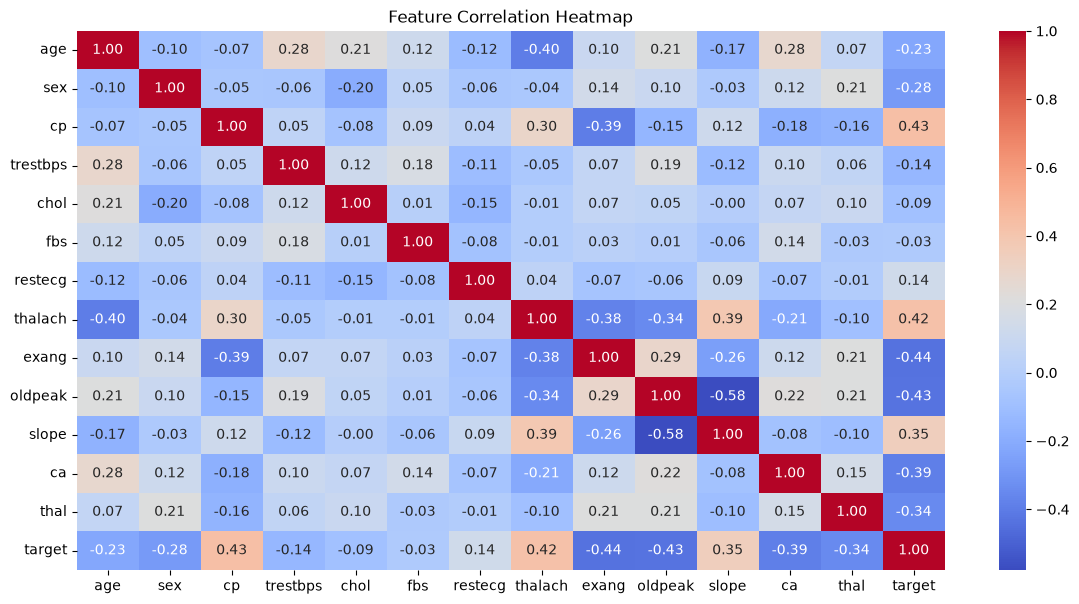

In [24]:
plt.figure(figsize=(14, 7))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Relationships(Subplot)

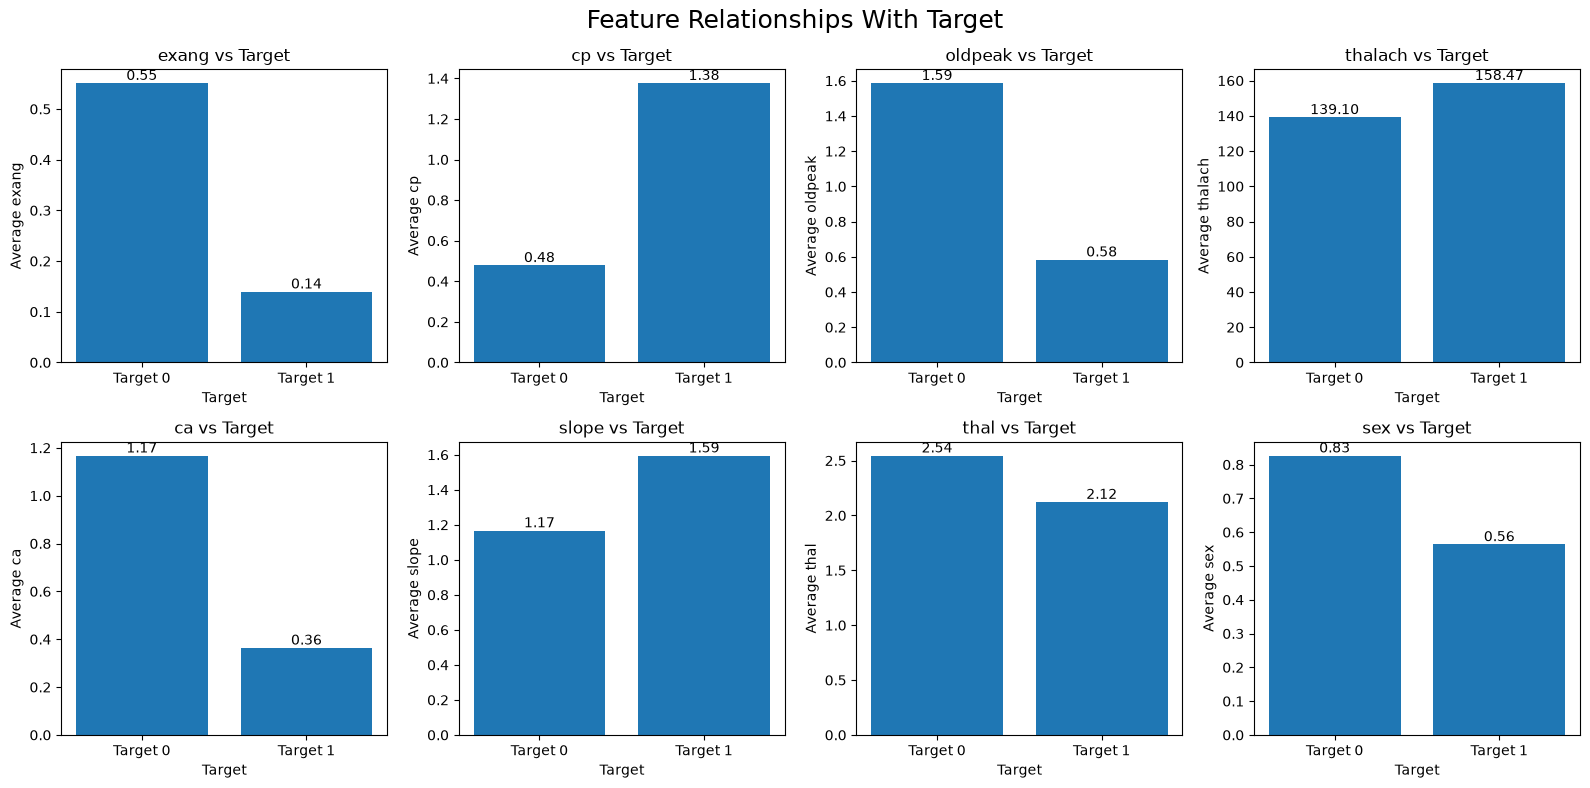

In [25]:
correlation_with_target = data.corr()["target"].drop("target").abs().sort_values(ascending = False)
top_features = correlation_with_target.head(8).index
fig, axes = plt.subplots(2, 4, figsize = (16, 8))
for ax, feature in zip(axes.flat, top_features):
    feature_means = data.groupby("target")[feature].mean()
    ax.bar(["Target 0", "Target 1"], feature_means.values)
    ax.set_title(f"{feature} vs Target")
    ax.set_xlabel("Target")
    ax.set_ylabel(f"Average {feature}")
    for i, value in enumerate(feature_means.values):
        ax.text(i, value, f"{value:.2f}", ha = "center", va = "bottom")
fig.suptitle("Feature Relationships With Target", fontsize = 18)
plt.tight_layout()
plt.show()

## 8 Models x 5 Scores Performance Comparison(Table)

In [26]:
models = {
    "Logistic Regression": model_01,
    "Ridge Classifier": model_02,
    "K-Nearest Neighbors": model_03,
    "Support Vector Classifier": model_04,
    "Gaussian Naive Bayes Classifier": model_05,
    "Decision Tree Classifier": model_06_1,
    "Random Forest Classifier": model_07_1,
    "Gradient Boosting Classifier": model_08_1
}
model_results = []
for model_name, model in models.items():
    y_test_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = model.decision_function(X_test)
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })
model_results = pd.DataFrame(model_results)
model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.885246,0.878788,0.90625,0.892308,0.926724
1,Ridge Classifier,0.868852,0.875000,0.87500,0.875000,0.934267
2,K-Nearest Neighbors,0.901639,0.933333,0.87500,0.903226,0.915409
3,Support Vector Classifier,0.868852,0.900000,0.84375,0.870968,0.931034
4,Gaussian Naive Bayes Classifier,0.868852,0.900000,0.84375,0.870968,0.894397
5,Decision Tree Classifier,0.852459,0.896552,0.81250,0.852459,0.843211
6,Random Forest Classifier,0.885246,0.878788,0.90625,0.892308,0.931034
7,Gradient Boosting Classifier,0.836066,0.866667,0.81250,0.838710,0.923491


## 8 Models x 4 Scores Performance Comparison(Grouped Bar Chart)

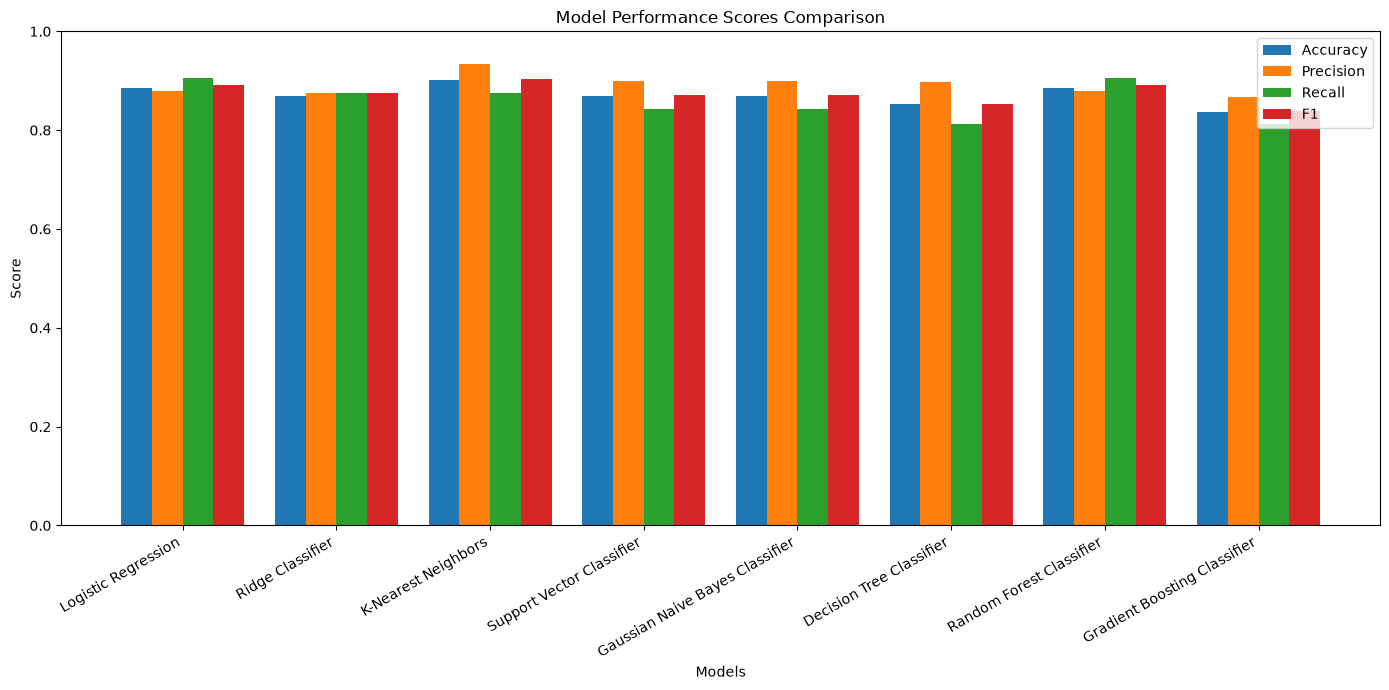

In [27]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(model_results["Model"]))
width = 0.2
plt.figure(figsize=(14, 7))
for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1.5) * width, model_results[metric], width, label=metric)
plt.title("Model Performance Scores Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(x, model_results["Model"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 8 Models x ROC-AUC Score Comparison(Bar Chart)

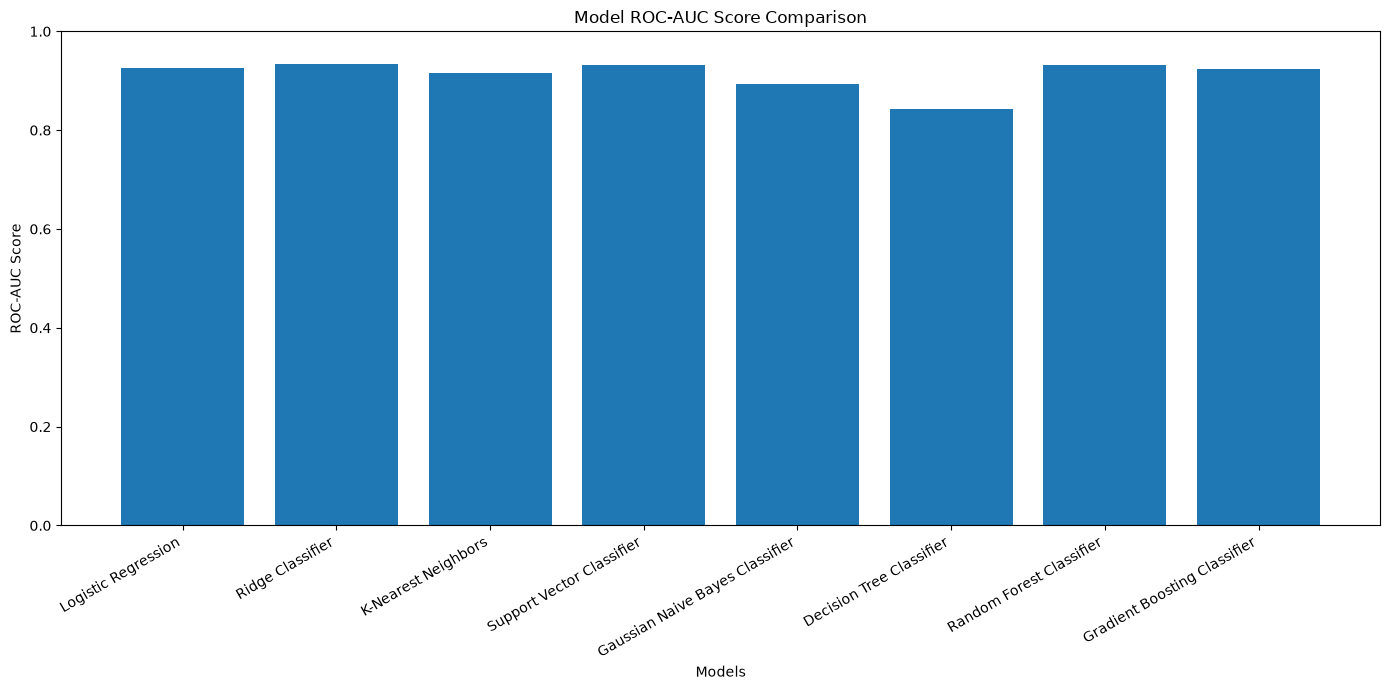

In [28]:
plt.figure(figsize=(14, 7))
plt.bar(model_results["Model"], model_results["ROC-AUC"])
plt.title("Model ROC-AUC Score Comparison")
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8 Models x ROC-AUC Curve(Chart)

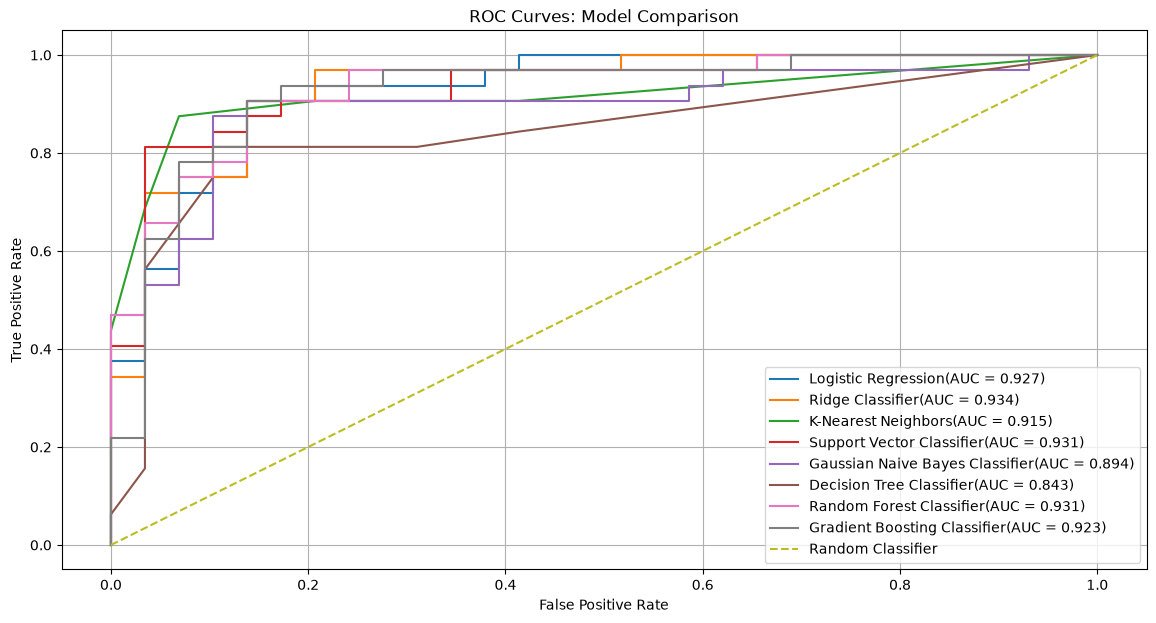

In [29]:
fpr_01, tpr_01, _ = roc_curve(y_test, y_test_prob_01)
fpr_02, tpr_02, _ = roc_curve(y_test, y_test_prob_02)
fpr_03, tpr_03, _ = roc_curve(y_test, y_test_prob_03)
fpr_04, tpr_04, _ = roc_curve(y_test, y_test_prob_04)
fpr_05, tpr_05, _ = roc_curve(y_test, y_test_prob_05)
fpr_06_1, tpr_06_1, _ = roc_curve(y_test, y_test_prob_06_1)
fpr_07_1, tpr_07_1, _ = roc_curve(y_test, y_test_prob_07_1)
fpr_08_1, tpr_08_1, _ = roc_curve(y_test, y_test_prob_08_1)
plt.figure(figsize=(14, 7))
plt.plot(fpr_01, tpr_01, label=f"Logistic Regression(AUC = {roc_auc_score(y_test, y_test_prob_01):.3f})")
plt.plot(fpr_02, tpr_02, label=f"Ridge Classifier(AUC = {roc_auc_score(y_test, y_test_prob_02):.3f})")
plt.plot(fpr_03, tpr_03, label=f"K-Nearest Neighbors(AUC = {roc_auc_score(y_test, y_test_prob_03):.3f})")
plt.plot(fpr_04, tpr_04, label=f"Support Vector Classifier(AUC = {roc_auc_score(y_test, y_test_prob_04):.3f})")
plt.plot(fpr_05, tpr_05, label=f"Gaussian Naive Bayes Classifier(AUC = {roc_auc_score(y_test, y_test_prob_05):.3f})")
plt.plot(fpr_06_1, tpr_06_1, label=f"Decision Tree Classifier(AUC = {roc_auc_score(y_test, y_test_prob_06_1):.3f})")
plt.plot(fpr_07_1, tpr_07_1, label=f"Random Forest Classifier(AUC = {roc_auc_score(y_test, y_test_prob_07_1):.3f})")
plt.plot(fpr_08_1, tpr_08_1, label=f"Gradient Boosting Classifier(AUC = {roc_auc_score(y_test, y_test_prob_08_1):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Model Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()

## 8 Models x Confusion Matrices(Subplot)

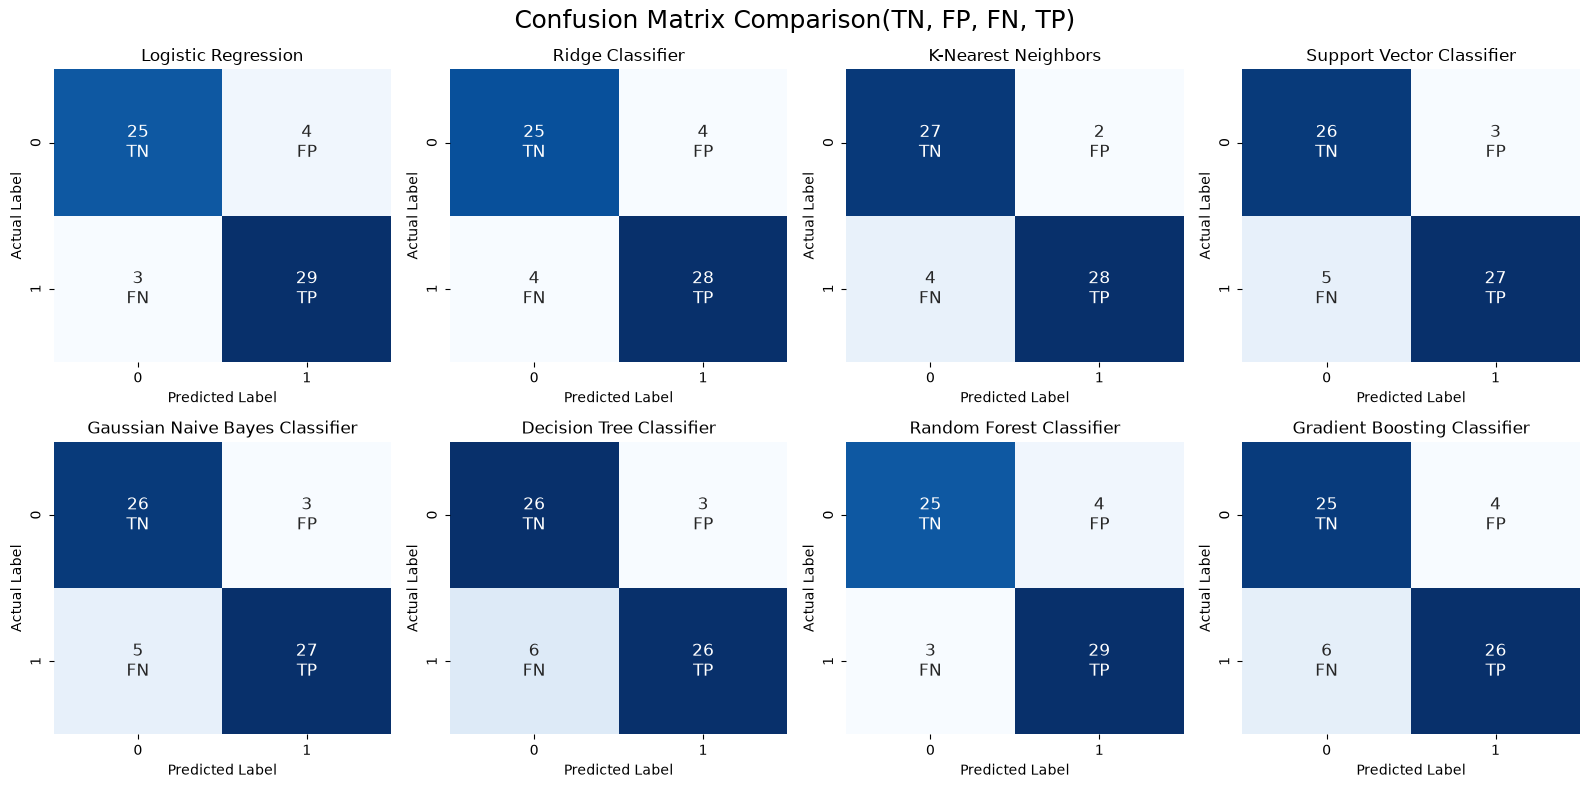

In [30]:
confusion_matrices = [
    confusion_matrix(y_test, y_test_pred_01),
    confusion_matrix(y_test, y_test_pred_02),
    confusion_matrix(y_test, y_test_pred_03),
    confusion_matrix(y_test, y_test_pred_04),
    confusion_matrix(y_test, y_test_pred_05),
    confusion_matrix(y_test, y_test_pred_06_1),
    confusion_matrix(y_test, y_test_pred_07_1),
    confusion_matrix(y_test, y_test_pred_08_1)
]
model_names = [
    "Logistic Regression",
    "Ridge Classifier",
    "K-Nearest Neighbors",
    "Support Vector Classifier",
    "Gaussian Naive Bayes Classifier",
    "Decision Tree Classifier",
    "Random Forest Classifier",
    "Gradient Boosting Classifier"
]
labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])
fig, axes = plt.subplots(2, 4, figsize = (16, 8))
for ax, cm, model_name in zip(axes.flat, confusion_matrices, model_names):
    annotations = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f"{cm[i, j]}\n{labels[i, j]}"
    sns.heatmap(cm, annot = annotations, fmt = "", cmap = "Blues", cbar = False, ax = ax, annot_kws = {"size": 12})
    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])
fig.suptitle("Confusion Matrix Comparison(TN, FP, FN, TP)", fontsize = 18)
plt.tight_layout()
plt.show()

## Tree-Based Models x Feature Importance(Subplot)

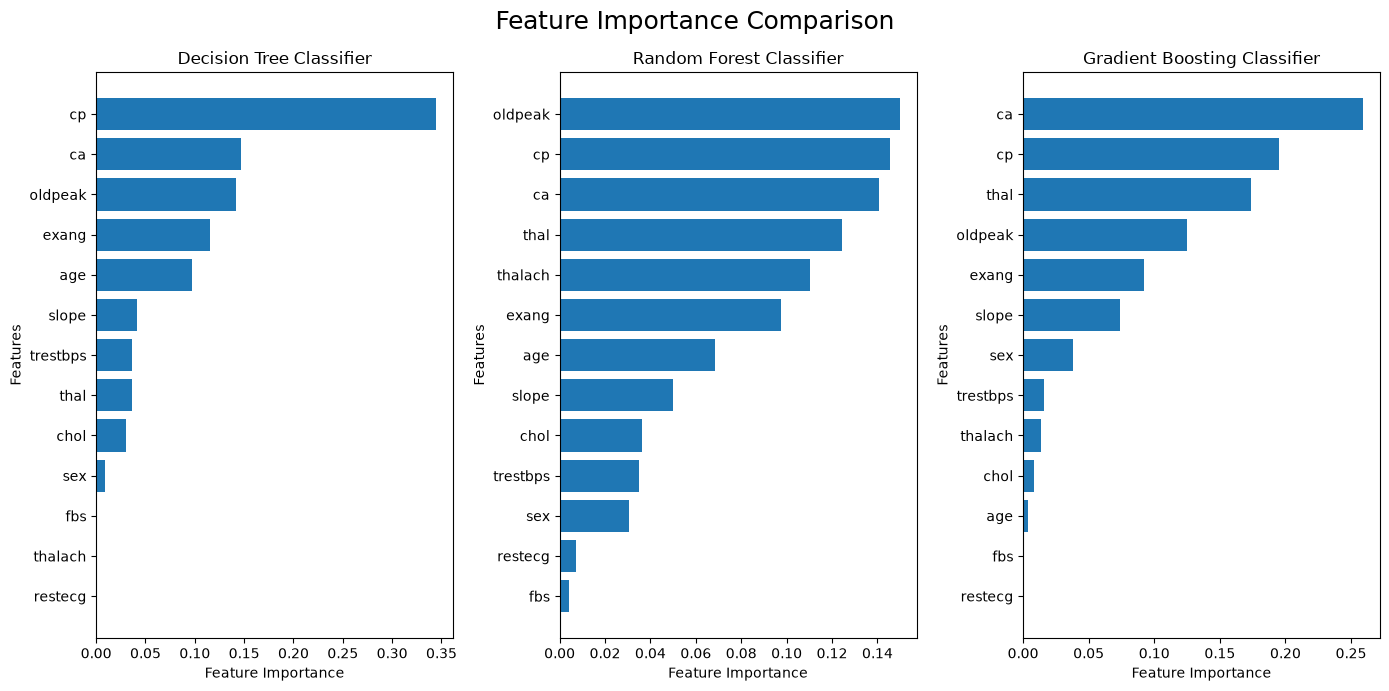

In [31]:
feature_names = X.columns
feature_importances = [
    model_06_1.feature_importances_,
    model_07_1.feature_importances_,
    model_08_1.feature_importances_
]
model_names = [
    "Decision Tree Classifier",
    "Random Forest Classifier",
    "Gradient Boosting Classifier"
]
fig, axes = plt.subplots(1, 3, figsize = (14, 7))
for ax, importance, model_name in zip(axes, feature_importances, model_names):
    importance_data = pd.Series(importance, index = feature_names).sort_values(ascending = True)
    ax.barh(importance_data.index, importance_data.values)
    ax.set_title(model_name)
    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("Features")
fig.suptitle("Feature Importance Comparison", fontsize = 18)
plt.tight_layout()
plt.show()

---

# Deployment

---

## Create "Final Models" Directory

In [32]:
FINAL_MODELS = Path("E:/Shabd/Academics/Semester 5/ITR Lab/Heart Disease Predictor/Final Models")
FINAL_MODELS.mkdir(exist_ok=True)
print('''"Final Models" directory is ready!''')

"Final Models" directory is ready!


## Prepare Bundles For The Final Models

In [33]:
model_01_bundle = {
    "model_name": "Logistic Regression",
    "model": model_01,
    "accuracy": accuracy_score(y_test, y_test_pred_01),
    "precision": precision_score(y_test, y_test_pred_01),
    "recall": recall_score(y_test, y_test_pred_01),
    "f1_score": f1_score(y_test, y_test_pred_01),
    "roc_auc": roc_auc_score(y_test, y_test_prob_01),
    "y_test": y_test.to_numpy(),
    "y_test_pred": y_test_pred_01,
    "y_test_prob": y_test_prob_01,
    "feature_names": X.columns.tolist()
}
model_03_bundle = {
    "model_name": "K-Nearest Neighbors",
    "model": model_03,
    "accuracy": accuracy_score(y_test, y_test_pred_03),
    "precision": precision_score(y_test, y_test_pred_03),
    "recall": recall_score(y_test, y_test_pred_03),
    "f1_score": f1_score(y_test, y_test_pred_03),
    "roc_auc": roc_auc_score(y_test, y_test_prob_03),
    "y_test": y_test.to_numpy(),
    "y_test_pred": y_test_pred_03,
    "y_test_prob": y_test_prob_03,
    "feature_names": X.columns.tolist()
}
model_07_1_bundle = {
    "model_name": "Random Forest Classifier",
    "model": model_07_1,
    "accuracy": accuracy_score(y_test, y_test_pred_07_1),
    "precision": precision_score(y_test, y_test_pred_07_1),
    "recall": recall_score(y_test, y_test_pred_07_1),
    "f1_score": f1_score(y_test, y_test_pred_07_1),
    "roc_auc": roc_auc_score(y_test, y_test_prob_07_1),
    "y_test": y_test.to_numpy(),
    "y_test_pred": y_test_pred_07_1,
    "y_test_prob": y_test_prob_07_1,
    "feature_names": X.columns.tolist()
}
print("Bundles of the final models are prepared successfully!")

Bundles of the final models are prepared successfully!


## Save The Bundles In "Final Models" Directory

In [34]:
joblib.dump(model_01_bundle, FINAL_MODELS / "Logistic_Regression.pkl")
joblib.dump(model_03_bundle, FINAL_MODELS / "KNN.pkl")
joblib.dump(model_07_1_bundle, FINAL_MODELS / "Random_Forest_Classifier.pkl")
print('''Bundles saved successfully in "Final Models"!''')

Bundles saved successfully in "Final Models"!


## Sanity Check For Bundles

In [35]:
logistic_regression_check = joblib.load(FINAL_MODELS / "Logistic_Regression.pkl")
knn_check = joblib.load(FINAL_MODELS / "KNN.pkl")
random_forest_classifier_check = joblib.load(FINAL_MODELS / "Random_Forest_Classifier.pkl")
print("Logistic Regression: ", logistic_regression_check["model_name"])
print("KNN: ", knn_check["model_name"])
print("Random Forest Classifier: ", random_forest_classifier_check["model_name"])

Logistic Regression:  Logistic Regression
KNN:  K-Nearest Neighbors
Random Forest Classifier:  Random Forest Classifier


## Sanity Check For Actual Predictions

In [36]:
input_data = (60, 1, 0, 145, 282, 0, 0, 142, 1, 2.8, 1, 2, 3)
input_data_df = pd.DataFrame([input_data], columns=X.columns)
print("Logistic Regression Prediction: ", logistic_regression_check["model"].predict(input_data_df)[0])
print("KNN Prediction: ", knn_check["model"].predict(input_data_df)[0])
print("Random Forest Classifier Prediction: ", random_forest_classifier_check["model"].predict(input_data_df)[0])

Logistic Regression Prediction:  0
KNN Prediction:  0
Random Forest Classifier Prediction:  0
